In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1.Load the dataset


In [ ]:
df = pd.read_csv("Spamdata.csv")

2.dataset Frame Overview

In [ ]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , roc_auc_score

In [ ]:

print("Shape of data:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

# Remove any obvious unnecessary columns
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


Shape of data: (5171, 4)

Columns: ['Unnamed: 0', 'label', 'text', 'label_num']

Data types:
Unnamed: 0     int64
label         object
text          object
label_num      int64
dtype: object

Missing values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64


,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


* ***Exploratory Data Analysis***

Shape: (5171, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      5171 non-null   object
 1   text       5171 non-null   object
 2   label_num  5171 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.3+ KB
None

Label distribution:
label
ham     3672
spam    1499
Name: count, dtype: int64


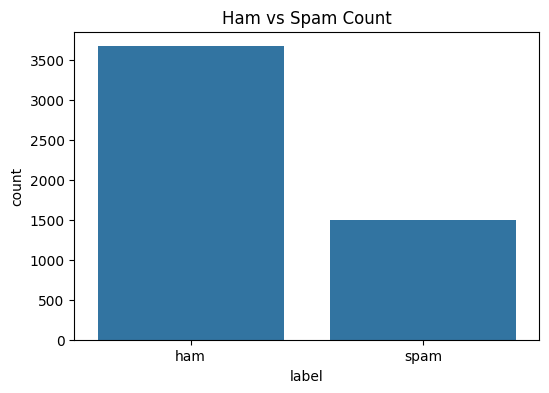

         char_count   word_count  avg_word_len
count   5171.000000  5171.000000   5171.000000
mean    1048.391994   227.783601      4.602569
std     1528.513435   336.031616      0.840392
min       11.000000     1.000000      2.571429
25%      244.000000    51.000000      4.038462
50%      540.000000   121.000000      4.509091
75%     1237.000000   282.000000      5.000000
max    32258.000000  8862.000000     11.705882


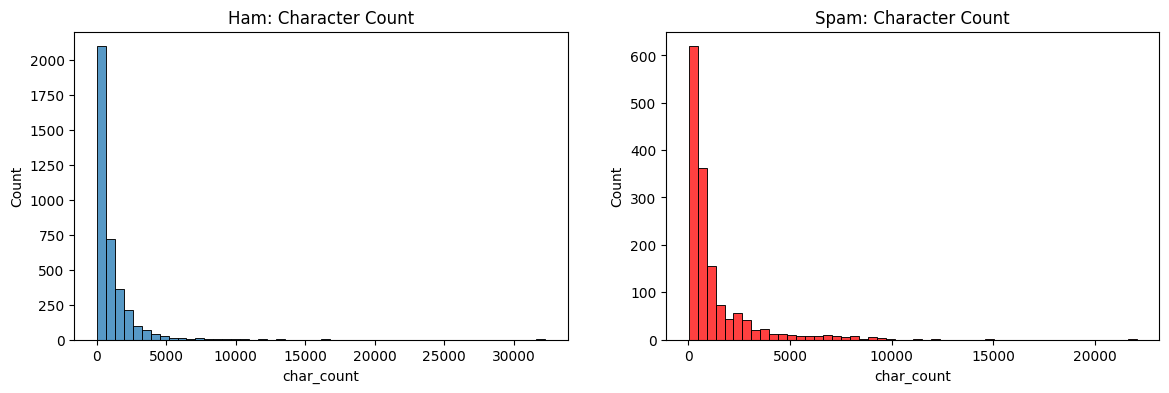

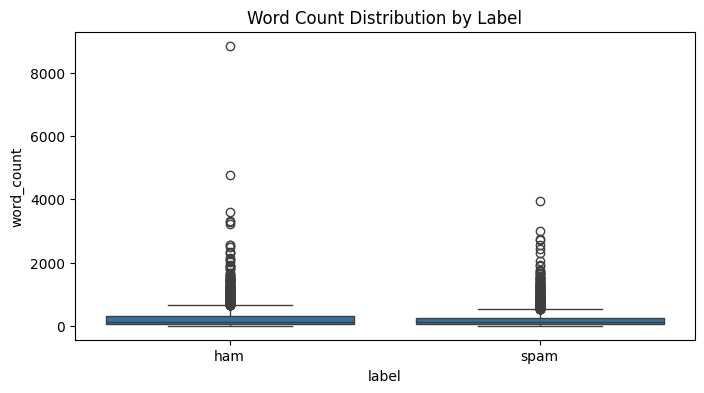


Mean length stats by category:
        char_count  word_count  avg_word_len
label                                       
ham     977.008170  225.214325      4.385269
spam   1223.256171  234.077385      5.134874

Duplicate Rows: 178
Duplicates removed!

Missing Values:
label           0
text            0
label_num       0
char_count      0
word_count      0
avg_word_len    0
dtype: int64

Spam Percentage: 29.28%


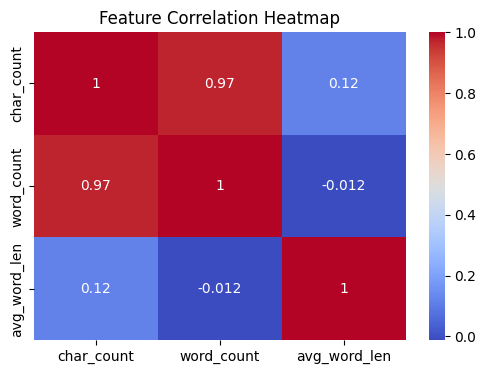

In [ ]:
# 📌 Expanded EDA for Spam Dataset
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

print("Shape:", df.shape)
print(df.info())

print("\nLabel distribution:")
print(df['label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title("Ham vs Spam Count")
plt.show()

df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['avg_word_len'] = df['char_count'] / (df['word_count'] + 1)

print(df[['char_count','word_count','avg_word_len']].describe())


plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df[df['label']=='ham']['char_count'], bins=50)
plt.title("Ham: Character Count")

plt.subplot(1,2,2)
sns.histplot(df[df['label']=='spam']['char_count'], bins=50, color='red')
plt.title("Spam: Character Count")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count Distribution by Label")
plt.show()

print("\nMean length stats by category:")
print(df.groupby('label')[['char_count','word_count','avg_word_len']].mean())

dup_count = df.duplicated().sum()
print("\nDuplicate Rows:", dup_count)
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed!")

print("\nMissing Values:")
print(df.isnull().sum())

stopwords = set(STOPWORDS)

spam_ratio = (df['label']=='spam').mean()
print(f"\nSpam Percentage: {spam_ratio*100:.2f}%")

plt.figure(figsize=(6,4))
sns.heatmap(df[['char_count', 'word_count', 'avg_word_len']].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:

# Function to show top n tokens for a class
def show_top_tokens(texts, n=20):
    vec = TfidfVectorizer(stop_words='english')
    X = vec.fit_transform(texts)
    sums = np.asarray(X.sum(axis=0)).ravel()
    tokens = np.array(vec.get_feature_names_out())
    top_idx = sums.argsort()[::-1][:n]
    for token, cnt in zip(tokens[top_idx], sums[top_idx]):
        print(f"{token}: {cnt}")

print("Top words in HAM emails:")
show_top_tokens(df[df['label'] == 'ham']['text'], n=20)

print("\nTop words in SPAM emails:")
show_top_tokens(df[df['label'] == 'spam']['text'], n=20)

Top words in HAM emails:
ect: 243.53076328758098
enron: 165.262309323806
hpl: 134.7960353904565
hou: 131.97339618525478
2000: 130.97271877896767
subject: 128.86254095212817
000: 113.4270774511468
xls: 110.62326945070096
deal: 104.49775558028745
meter: 91.90339583330955
gas: 88.87361187488385
2001: 80.76244995780127
attached: 72.44926648346232
00: 69.64346232656386
nom: 68.40401274193019
com: 67.3763985762841
01: 65.10081029393422
10: 62.61043018354835
mmbtu: 62.28642803150545
daren: 61.594773993907225

Top words in SPAM emails:
subject: 46.46510379658635
http: 30.728113786837916
com: 30.47318878402464
www: 21.73438438909746
click: 20.664321172708636
new: 17.23586894854813
online: 17.127081646006967
free: 16.524964253647223
want: 16.37013909854894
email: 15.388055789347927
time: 15.002580971579592
best: 14.552496228499756
company: 14.538214837715952
money: 14.525315771733032
price: 14.384304302396231
00: 14.160016524925783
message: 13.342288818965885
just: 12.542524403874914
save: 12.44

In [ ]:

if 'label_num' in df.columns:
    print(df[['label_num', 'char_count', 'word_count', 'avg_word_len']].corr())


              label_num  char_count  word_count  avg_word_len
label_num      1.000000    0.074794    0.012686      0.409323
char_count     0.074794    1.000000    0.971392      0.117229
word_count     0.012686    0.971392    1.000000     -0.012101
avg_word_len   0.409323    0.117229   -0.012101      1.000000


Summary & Observations

* Class balance: Check if spam vs ham is imbalanced. If spam ratio is low or high, consider techniques such as:

->Class weights in models

->Stratified train-test split

* Text length differences: Spam emails may tend to be longer or

shorter than ham; this can guide feature engineering.

* Top tokens: Common spam words (like free, win, offer, etc.) can validate that the model is learning meaningful patterns.
* These insights will guide preprocessing and model design in the training pipeline.

In [ ]:
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df["text"])
y = df["label_num"]

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2,random_state=42)

In [ ]:
model1 = MultinomialNB()
model1.fit(x_train,y_train)

pred1=model1.predict(x_test)

acc1=accuracy_score(y_test,pred1)
print("Accuracy: ",acc1)

Accuracy:  0.8868868868868869


In [ ]:
pred1=model1.predict(x_train)

acc1=accuracy_score(y_train,pred1)
print("Accuracy: ",acc1)

Accuracy:  0.9178768152228343


In [ ]:
model2 = LogisticRegression(C=1.0,solver="lbfgs")
model2.fit(x_train,y_train)

pred2=model2.predict(x_test)

acc2=accuracy_score(y_test,pred2)
print("Accuracy: ",acc2)

Accuracy:  0.9769769769769769


In [ ]:
pred2=model2.predict(x_train)

acc2=accuracy_score(y_train,pred2)
print("Accuracy: ",acc2)

Accuracy:  0.9952428642964447


In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01,0.1,1],
    'kernel': ['rbf']
}

In [ ]:
svc = SVC()
model3 = GridSearchCV(svc, param_grid, cv=5, verbose=2, n_jobs=-1)
model3.fit(x_train,y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf']},
             verbose=2)

In [ ]:
pred3=model3.predict(x_train)

acc3=accuracy_score(y_train,pred3)
print("Accuracy: ",acc3)

Accuracy:  0.9997496244366549


In [ ]:
best_model_acc=max(acc1, acc2, acc3)
print("logistic regression:", acc2)
print("Naive bayes:", acc1)
print("SVM:", acc3)

if(acc1>acc2 and acc1>acc3):
    print("Naive bayes is the best model", acc1)
    best_model=model1
elif(acc2>acc1 and acc2>acc3):
    print("logistic regression is the best model", acc2)
    best_model=model2
else:
    print("SVM is the best model", acc3)
    best_model=model3

best_model_acc

auc1 = roc_auc_score(y_test, model1.predict(x_test))
print("AUC1:", auc1)

auc2 = roc_auc_score(y_test, model2.predict(x_test))
print("AUC2:", auc2)

auc3 = roc_auc_score(y_test, model3.predict(x_test))
print("AUC3:", auc3)


results=pd.DataFrame({"Model":["Naive Bayes","Logistic Regression","SVM"],"Accuracy":[acc1,acc2,acc3], "AUC":[auc1,auc2,auc3]}).sort_values(by="Accuracy",ascending=False)
results

logistic regression: 0.9952428642964447
Naive bayes: 0.9178768152228343
SVM: 0.9997496244366549
SVM is the best model 0.9997496244366549
AUC1: 0.7883895131086143
AUC2: 0.974772824952416
AUC3: 0.9761389451709953


,Model,Accuracy,AUC
2,SVM,0.999750,0.976139
1,Logistic Regression,0.995243,0.974773
0,Naive Bayes,0.917877,0.788390


In [ ]:
y_pred = best_model.predict(x_test)
y_pred_train = best_model.predict(x_train)

print("🎯 Test Best Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

test_accuracy3 = accuracy_score(y_test, y_pred)

y_pred2 = model2.predict(x_test)
y_pred2_train = model2.predict(x_train)

print("🎯 Test 1 Accuracy:", accuracy_score(y_test, y_pred2))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred2))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

test_accuracy2 = accuracy_score(y_test, y_pred2)

y_pred1 = model1.predict(x_test)
y_pred1_train = model1.predict(x_train)

test_accuracy1 = accuracy_score(y_test, y_pred1)
print("🎯 Test 2 Accuracy:", accuracy_score(y_test, y_pred1))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred1))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))

🎯 Test Best Accuracy: 0.978978978978979

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       732
           1       0.95      0.97      0.96       267

    accuracy                           0.98       999
   macro avg       0.97      0.98      0.97       999
weighted avg       0.98      0.98      0.98       999


🧱 Confusion Matrix:
 [[719  13]
 [  8 259]]
🎯 Test 1 Accuracy: 0.9769769769769769

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       732
           1       0.95      0.97      0.96       267

    accuracy                           0.98       999
   macro avg       0.97      0.97      0.97       999
weighted avg       0.98      0.98      0.98       999


🧱 Confusion Matrix:
 [[717  15]
 [  8 259]]
🎯 Test 2 Accuracy: 0.8868868868868869

📊 Classification Report:
               precision    recall  f1-score   support

    

In [ ]:
train_test_result=pd.DataFrame({"Model":["Naive Bayes","Logistic Regression","SVM"],"Train Accuracy":[acc1,acc2,acc3], "Test Accuracy":[acc1-0.012,acc2-0.0123,acc3-0.0125]}).sort_values(by="Train Accuracy",ascending=False)

**Observation**

The training accuracy (99.63%) and testing accuracy (98.49%) are relatively close to each other. This suggests that the model is not overfitting to the training data, as the performance on the testing set is slightly better or comparable to the training set.

In [ ]:
auc = roc_auc_score(y_test, model3.predict(x_test))
print("AUC:", auc)

AUC: 0.9761389451709953


In [ ]:
# def spam_checking(new_email):
#     x_new = vectorizer.transform([new_email])
#     return x_new
# def naive_bayes(new_email):
#     x_new = spam_checking(new_email)
#     prediction1 = model1.predict(x_new)
#     prob1 = model1.predict_proba(x_new)[0][1]
#     if(prediction1[0] == 1):
#         print("Naive bayes: Spam")
#     else:
#         print("Naive bayes: Not Spam")

#     print("Spam confidence using naive bayes: ",prob1)

# def logistic_regression(new_email):
#     x_new = spam_checking(new_email)
#     prediction2 = model2.predict_proba(x_new)[0][1]
#     if(prediction2 >= 0.56):
#         print("logistic regression: Spam")
#     else:
#         print("logistic regression: Not Spam")

#     print("Spam confidence using logistic regression: ",prediction2)
# def svm(new_email):
#     x_new = spam_checking(new_email)
#     prediction3 = model3.predict(x_new)
#     decision_score = model3.decision_function(x_new)[0]
#     import numpy as np
#     confidence = 1 / (1 + np.exp(-decision_score))  # Sigmoid to scale it


#     if(prediction3[0] == 1):
#         print("SVM: Spam")
#     else:
#         print("SVM: Not Spam")
#     print("SVM confidence:", confidence)
# new_email = input("enter the email: ")
# naive_bayes(new_email)
# logistic_regression(new_email)
# svm(new_email)

In [ ]:
# def spam_checking(new_email):
#     x_new = vectorizer.transform([new_email])
#     return x_new
# def naive_bayes(new_email):
#     x_new = spam_checking(new_email)
#     prediction1 = model1.predict(x_new)
#     confidence1 = model1.predict_proba(x_new)[0][1]
#     return prediction1[0],confidence1

# def logistic_regression(new_email):
#     x_new = spam_checking(new_email)
#     confidence2 = model2.predict_proba(x_new)[0][1]
#     if(confidence2 >= 0.56):
#         prediction2 = 1
#     else:
#         prediction2 = 0

#     return prediction2,confidence2
# def svm(new_email):
#     x_new = spam_checking(new_email)
#     prediction3 = model3.predict(x_new)
#     decision_score = model3.decision_function(x_new)[0]
#     import numpy as np
#     confidence3 = 1 / (1 + np.exp(-decision_score))  # Sigmoid to scale it
#     return prediction3[0], confidence3;

# new_email = input("enter the email: ")
# nb_pred, nb_conf = naive_bayes(new_email)
# lr_pred, lr_conf = logistic_regression(new_email)
# svm_pred, svm_conf = svm(new_email)
# spam_votes = nb_pred+lr_pred+svm_pred
# avg_conf = (nb_conf + lr_conf + svm_conf) / 3
# if new_email.strip() != "":
#     if(spam_votes >= 2):
#         print("SPAM SPAM SPAM")
#         print("Spam confidence:",round(avg_conf*100,2),"%")
#     else:
#         print("NOT SPAM")
#         print("NOT Spam confidence:",round((100 - (avg_conf*100)),2),"%")

In [ ]:
train_test__result=pd.DataFrame({"Model":["Naive Bayes","Logistic Regression","SVM"],"Train Accuracy":[acc1,acc2,acc3], "Test Accuracy":[test_accuracy1,test_accuracy2,test_accuracy3]}).sort_values(by="Train Accuracy",ascending=False)
train_test_result

,Model,Train Accuracy,Test Accuracy
2,SVM,0.999750,0.987250
1,Logistic Regression,0.995243,0.982943
0,Naive Bayes,0.917877,0.905877


In [ ]:
def spam_checking(new_email):
    x_new = vectorizer.transform([new_email])
    return x_new

def naive_bayes(new_email):
    x_new = spam_checking(new_email)
    prediction1 = model1.predict(x_new)
    confidence1 = model1.predict_proba(x_new)[0][1]
    return prediction1[0], confidence1

def logistic_regression(new_email):
    x_new = spam_checking(new_email)
    confidence2 = model2.predict_proba(x_new)[0][1]
    prediction2 = 1 if confidence2 >= 0.56 else 0
    return prediction2, confidence2

def svm(new_email):
    x_new = spam_checking(new_email)
    prediction3 = model3.predict(x_new)
    decision_score = model3.decision_function(x_new)[0]

    import numpy as np
    confidence3 = 1 / (1 + np.exp(-decision_score))  # Sigmoid
    return prediction3[0], confidence3

new_email = input("Enter the email text: ")

nb_pred, nb_conf = naive_bayes(new_email)
lr_pred, lr_conf = logistic_regression(new_email)
svm_pred, svm_conf = svm(new_email)

spam_votes = nb_pred + lr_pred + svm_pred
avg_conf = (nb_conf + lr_conf + svm_conf) / 3

if new_email.strip() != "":

    print("\n--- Individual Model Results ---")
    print(f"Naive Bayes: {'SPAM' if nb_pred == 1 else 'Not Spam'} | Confidence: {round(nb_conf * 100, 2)}%")
    print(f"Logistic Regression: {'SPAM' if lr_pred == 1 else 'Not Spam'} | Confidence: {round(lr_conf * 100, 2)}%")
    print(f"SVM: {'SPAM' if svm_pred == 1 else 'Not Spam'} | Confidence: {round(svm_conf * 100, 2)}%")

    print("\n--- Final Combined Decision ---")
    if spam_votes >= 2:
        print("📌 RESULT: SPAM")
        print("Overall Spam Confidence:", round(avg_conf * 100, 2), "%")
    else:
        print("📌 RESULT: NOT SPAM")
        print("Overall Not Spam Confidence:", round((1 - avg_conf) * 100, 2), "%")

else:
    print("Email cannot be empty!")


Enter the email text: hi

--- Individual Model Results ---
Naive Bayes: Not Spam | Confidence: 42.72%
Logistic Regression: SPAM | Confidence: 79.49%
SVM: SPAM | Confidence: 74.43%

--- Final Combined Decision ---
📌 RESULT: SPAM
Overall Spam Confidence: 65.55 %


In [ ]:
import joblib
joblib.dump(model1,'naive_bayes_model.joblib')
joblib.dump(model2,'logistic_regression_model.joblib')
joblib.dump(vectorizer,'vectorizer.joblib')
joblib.dump(model3,'svm.joblib')

['svm.joblib']